In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")

# print top row show
df.head()

df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler


le = LabelEncoder()
# df['date'] = le.fit_transform(df['data'])
df['street'] =le.fit_transform(df['street'])
df['city'] = le.fit_transform(df['city'])
df['statezip'] =le.fit_transform(df['statezip'])
df['country'] = le.fit_transform(df['country']) 
# print("after encoding")
# df.head()
# print("after data type")
# df.dtypes




after encoding


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,1522,36,62,0
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,3899,35,58,0
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,2291,18,26,0
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4263,3,7,0
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,4352,31,31,0


In [27]:

X = df.drop(['price','date'],axis=1)

y = df['price']

print("shape of x ",X.shape)
print("shape of y ",y.shape)



shape of x  (4600, 16)
shape of y  (4600,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

print("X_trian ",X_train.shape)
print("X_test ",X_test.shape)
print("y_trian ",y_train.shape)
print("y_test ",y_test.shape)

X_trian  (3680, 16)
X_test  (920, 16)
y_trian  (3680,)
y_test  (920,)


In [34]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)



In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)
lr.coef_
lr.intercept_

np.float64(549285.3945384723)

In [43]:
pred1 = lr.predict([X_test[0, :]])
pred = lr.predict(X_test)
print(pred)

[ 2.22916768e+08  2.79047514e+08  2.70375941e+08 -2.66910003e+08
  3.55568404e+08  3.93119090e+08  1.30078914e+08  2.89700064e+08
  2.54805095e+08  3.62631460e+08  1.94280861e+08 -1.33196112e+08
  2.33581032e+07  2.43944958e+08  1.78215253e+08  6.39272173e+07
  2.14225393e+08  1.95670740e+08  3.39624465e+08  1.83601541e+08
  9.82913360e+07  1.22321689e+08 -5.34782053e+08  1.42242386e+08
  4.50015276e+08 -4.67811802e+07  3.85331543e+08 -2.01293233e+08
  1.69737154e+08  3.29610984e+08 -1.07704976e+07  6.18718883e+07
  2.32228411e+08  1.95419753e+08 -3.37056782e+08  2.66815950e+08
 -5.27221861e+08 -1.11161438e+07 -1.28927265e+08  1.45810140e+08
  6.46560410e+07  1.50073558e+08 -3.88867670e+08  2.45493461e+08
  5.28985497e+07  1.01177021e+08  1.36886496e+08 -2.99117559e+08
 -3.83520474e+07 -1.27665174e+08  2.98445605e+08 -6.25497665e+08
  6.55140364e+07  2.21353956e+08 -1.48496494e+08  2.09640167e+08
  3.39357335e+08  2.77646406e+08 -2.00294685e+07  1.26834225e+08
  1.43840919e+08  4.33031

In [39]:
lr.score(X_test,y_test)

-1540477.009999407

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3680, 16) and arg 1 with shape (920,).

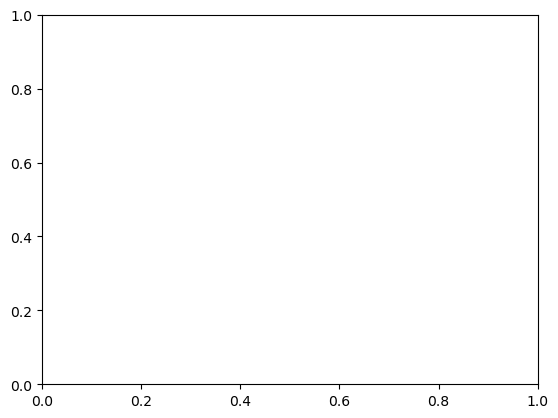

In [ ]:
import matplotlib.pyplot as plt

plt.hist(pred,color='g')


plt.xlabel("X_train")
plt.ylabel("Predicted")
plt.show()
